# 14회차 — 산점도와 박스플롯

상관계수가 놓친 곡선·그룹 차이를 눈으로 확인하고,
그룹 차이를 Kruskal-Wallis로 검정한다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import platform, os
import warnings
warnings.filterwarnings("ignore")

def set_korean_font():
    system = platform.system()
    if system == "Darwin":
        plt.rcParams["font.family"] = "AppleGothic"
    elif system == "Windows":
        plt.rcParams["font.family"] = "Malgun Gothic"
    else:
        plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False

sns.set_style("whitegrid")   # ※ set_style이 font.family를 덮어쓰므로 폰트보다 먼저 호출
set_korean_font()
os.makedirs("../../figures", exist_ok=True)

In [2]:
df = pd.read_csv("../../data/processed/3_eda/step7_corr.csv",
                 encoding="utf-8-sig", low_memory=False)
for c in ["ABATT_DATE","BIRTH_YMD","JUDGE_DATE"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")
if "grade_num" not in df.columns:
    grade_map = {"1++A":15,"1++B":14,"1++C":13,"1+A":12,"1+B":11,"1+C":10,
                 "1A":9,"1B":8,"1C":7,"2A":6,"2B":5,"2C":4,"3A":3,"3B":2,"3C":1,"등외":0}
    df["grade_num"] = df["LAST_GRADE"].map(grade_map)

grade_order = ["1++A","1++B","1++C","1+A","1+B","1+C",
               "1A","1B","1C","2A","2B","2C","3A","3B","3C","등외"]
grade_order = [g for g in grade_order if g in df["LAST_GRADE"].unique()]
print(f"데이터: {df.shape}")

데이터: (2408699, 45)


## 1. 산점도용 샘플 만들기 (과밀 방지)

240만 행을 다 찍으면 새까매서 안 보인다. 2만 개만 뽑는다.
박스플롯·검정은 전체 데이터로 한다.

In [3]:
df_sample = df.sample(n=min(20000, len(df)), random_state=42)
print(f"산점도용 샘플: {df_sample.shape}")

산점도용 샘플: (20000, 45)


## 2. 가격 vs 핵심 변수 산점도

연속값 COST_AMT를 세로축에 놓고 본다. 빨간 선은 추세선.

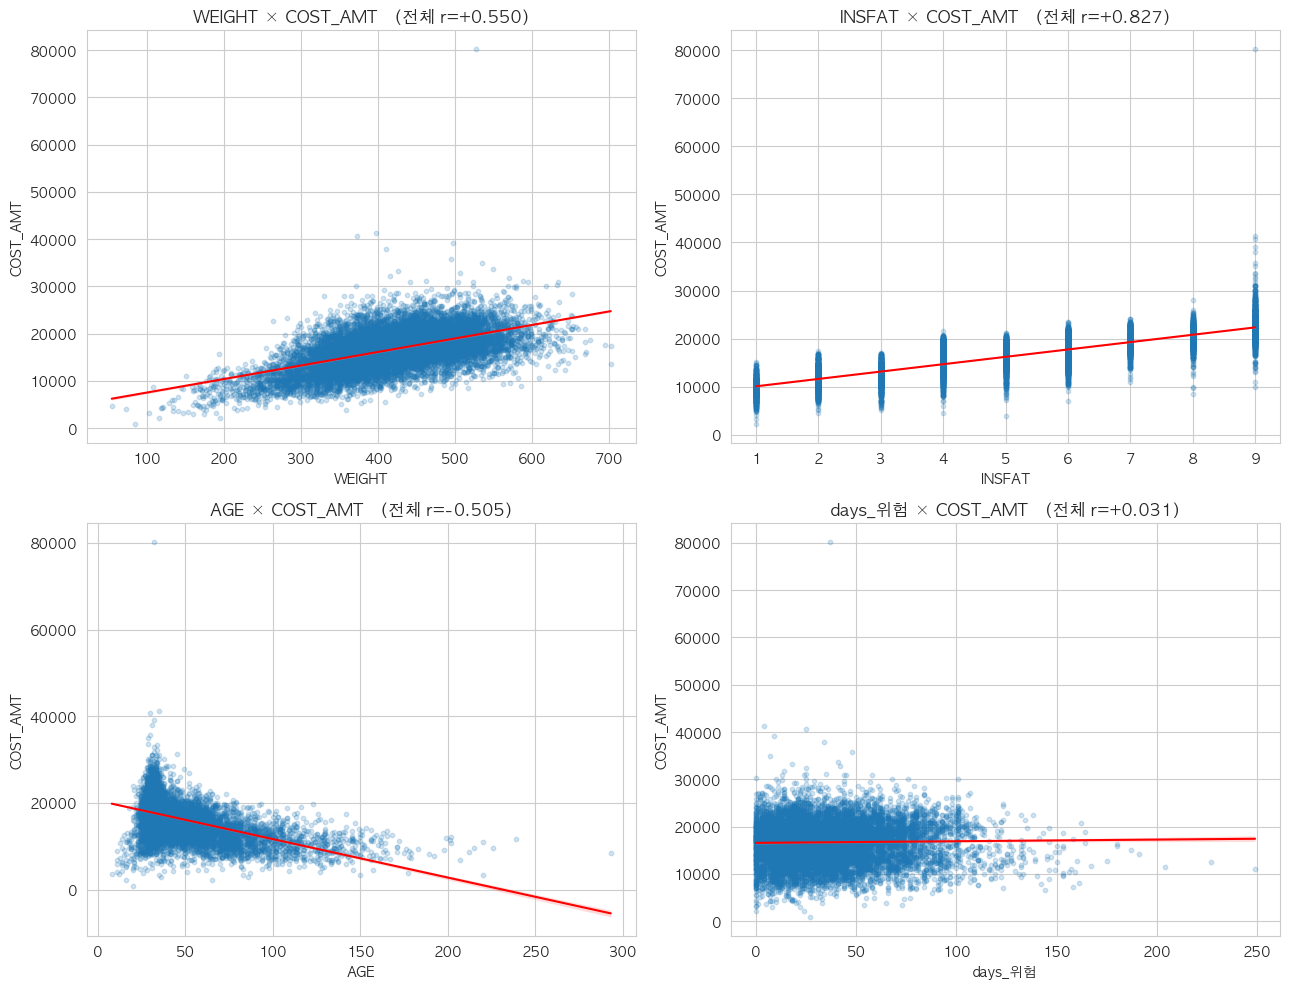

In [4]:
target = "COST_AMT"
# ※ days_위험은 절대일수 — 17회차에서 비율로 다시 봄
key_pairs = [(x, target) for x in ["WEIGHT","INSFAT","AGE","days_위험"]
             if x in df.columns]
n = len(key_pairs)
fig, axes = plt.subplots((n+1)//2, 2, figsize=(13, 5*((n+1)//2)))
axes = axes.flatten()
for i, (x, y) in enumerate(key_pairs):
    sns.regplot(data=df_sample, x=x, y=y, ax=axes[i],
                scatter_kws={"alpha":0.2,"s":10},
                line_kws={"color":"red","linewidth":1.5})
    r = df[[x, y]].corr().iloc[0, 1]   # 상관은 전체로
    axes[i].set_title(f"{x} × {y}   (전체 r={r:+.3f})")
for j in range(n, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig("../../figures/14_scatter_key.png", dpi=100, bbox_inches="tight")
plt.show()

## 3. 곡선 관계 확인 — LOWESS

빨간 곡선이 휘어 있으면 직선이 아니라는 뜻.
※ statsmodels가 설치돼 있어야 작동(00회차 참고).

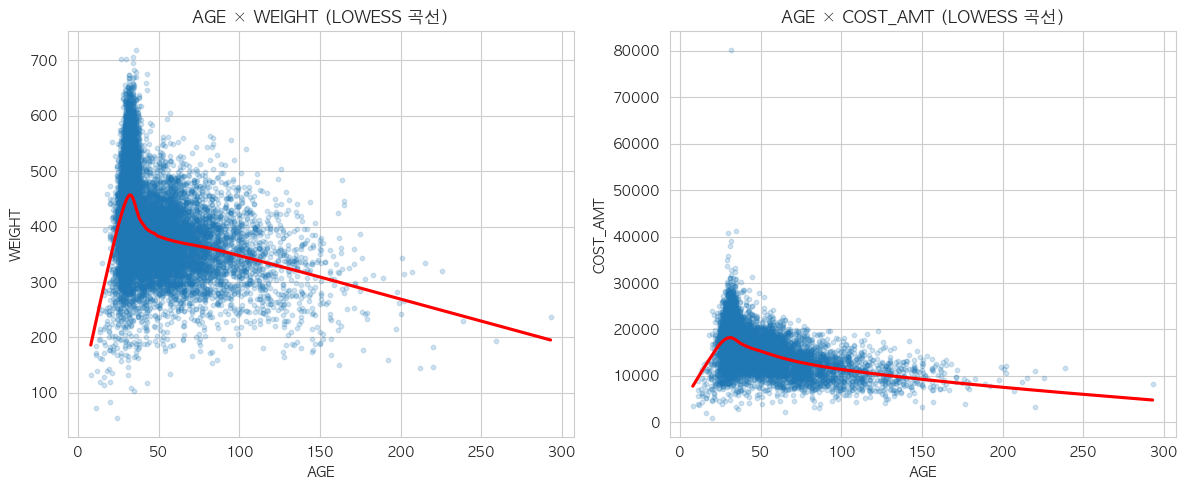

In [5]:
suspect_pairs = [(x, y) for x, y in [("AGE","WEIGHT"), ("AGE", target)]
                 if x in df.columns and y in df.columns]
fig, axes = plt.subplots(1, len(suspect_pairs),
                         figsize=(6*len(suspect_pairs), 5))
if len(suspect_pairs) == 1:
    axes = [axes]
for ax, (x, y) in zip(axes, suspect_pairs):
    sns.regplot(data=df_sample, x=x, y=y, ax=ax, lowess=True,
                scatter_kws={"alpha":0.2,"s":10}, line_kws={"color":"red"})
    ax.set_title(f"{x} × {y} (LOWESS 곡선)")
plt.tight_layout()
plt.savefig("../../figures/14_lowess.png", dpi=100, bbox_inches="tight")
plt.show()

## 4. 등급별 형질 박스플롯 (핵심)

※ 육질(BACKFAT/REA/INSFAT)은 등급 정답지라 계단처럼 나오는 게 당연 — 제출 모델엔 못 씀.
   WEIGHT/AGE는 도축 전에도 아는 값이라 예측에 쓸 수 있음.

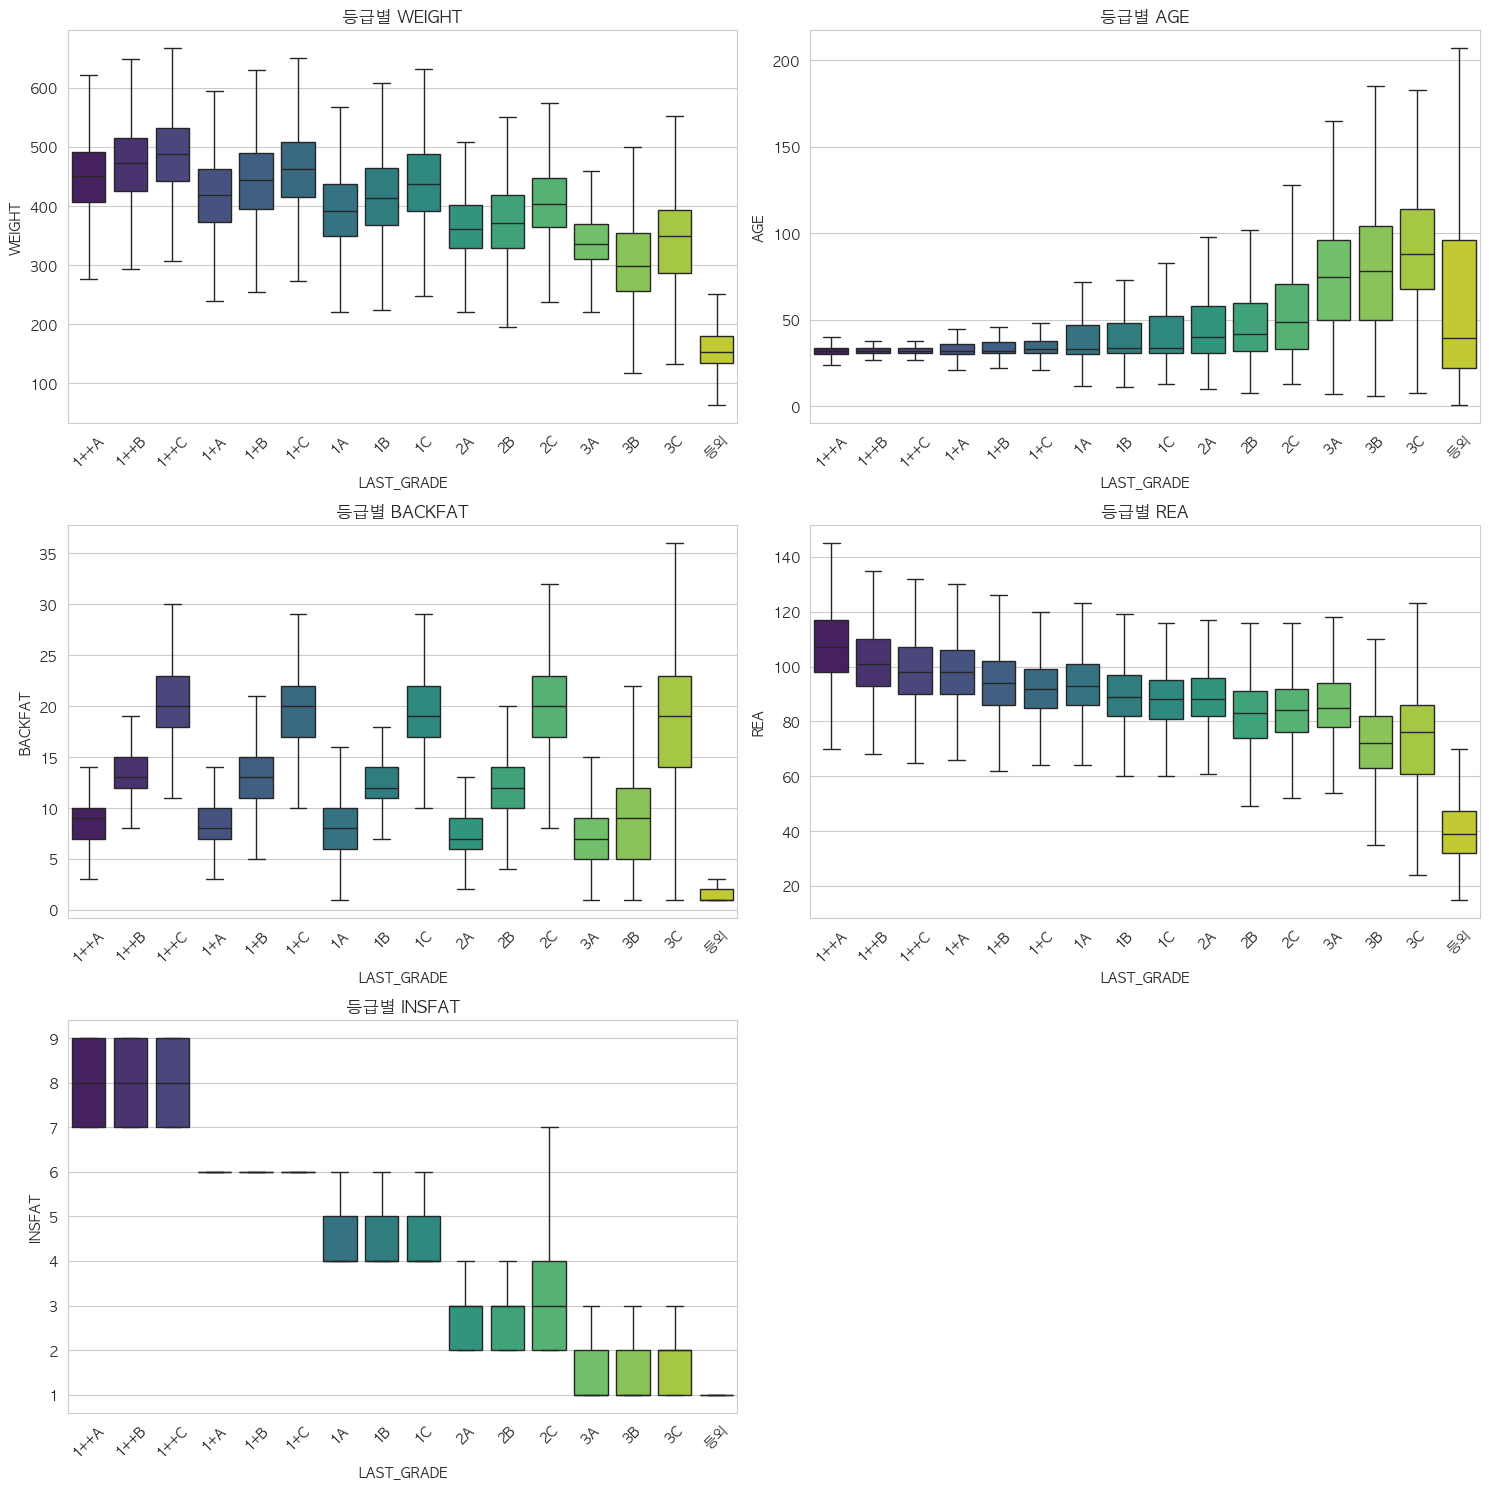

In [6]:
# ※ palette는 hue=동일컬럼 + legend=False로 써야 최신 seaborn에서 경고 없음
vars_to_compare = [v for v in ["WEIGHT","AGE","BACKFAT","REA","INSFAT"]
                   if v in df.columns]
n = len(vars_to_compare)
fig, axes = plt.subplots((n+1)//2, 2, figsize=(15, 5*((n+1)//2)))
axes = axes.flatten()
for i, var in enumerate(vars_to_compare):
    sns.boxplot(data=df, x="LAST_GRADE", y=var, order=grade_order,
                hue="LAST_GRADE", hue_order=grade_order,
                palette="viridis", legend=False,
                ax=axes[i], showfliers=False)
    axes[i].set_title(f"등급별 {var}")
    axes[i].tick_params(axis="x", rotation=45)
for j in range(n, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig("../../figures/14_box_grade.png", dpi=100, bbox_inches="tight")
plt.show()

## 5. 도축 계절별 가격 박스플롯

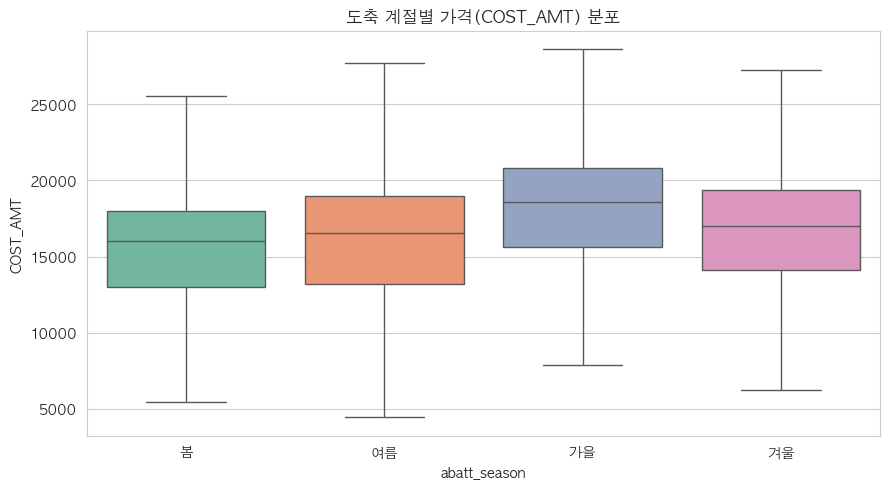

In [7]:
month_to_season = {12:"겨울",1:"겨울",2:"겨울", 3:"봄",4:"봄",5:"봄",
                   6:"여름",7:"여름",8:"여름", 9:"가을",10:"가을",11:"가을"}
df["abatt_season"] = df["ABATT_DATE"].dt.month.map(month_to_season)
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="abatt_season", y=target, order=["봄","여름","가을","겨울"],
            hue="abatt_season", hue_order=["봄","여름","가을","겨울"],
            palette="Set2", legend=False, showfliers=False)
plt.title("도축 계절별 가격(COST_AMT) 분포")
plt.tight_layout()
plt.savefig("../../figures/14_box_season.png", dpi=100, bbox_inches="tight")
plt.show()

## 6. 시도별 가격 박스플롯

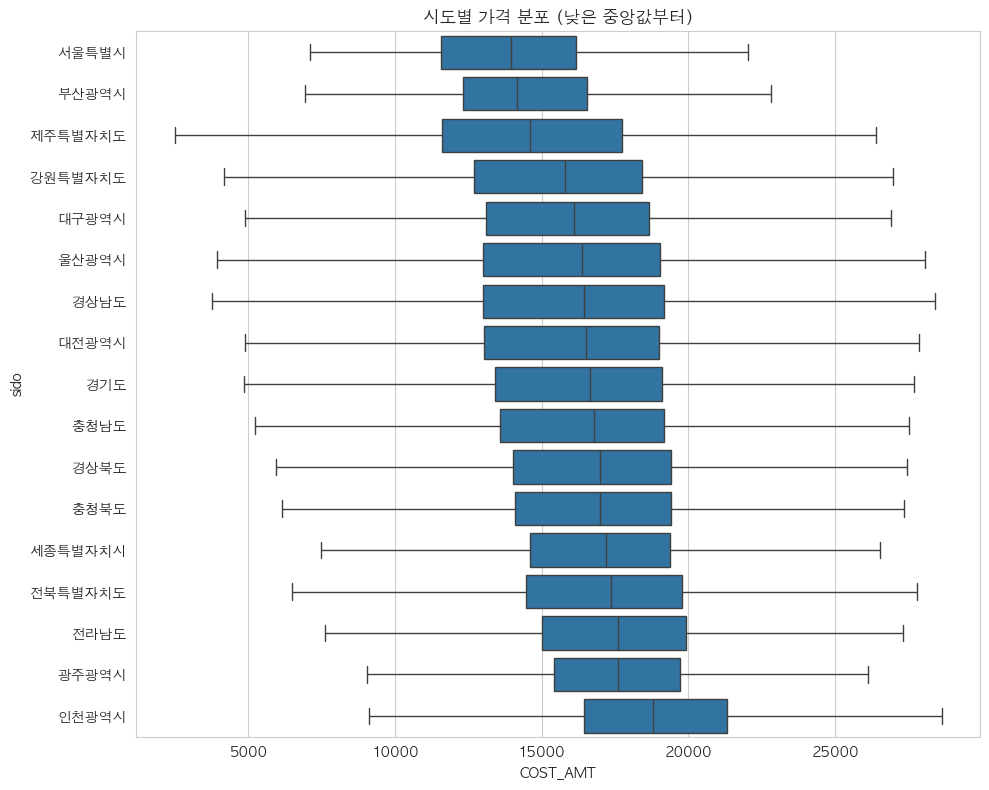

In [8]:
sido_order = df.groupby("sido")[target].median().sort_values().index
plt.figure(figsize=(10, 8))
sns.boxplot(data=df, y="sido", x=target, order=sido_order, showfliers=False)
plt.title("시도별 가격 분포 (낮은 중앙값부터)")
plt.tight_layout()
plt.savefig("../../figures/14_box_sido.png", dpi=100, bbox_inches="tight")
plt.show()

## 7. 성별 차이 박스플롯 (거세 / 암 / 수)

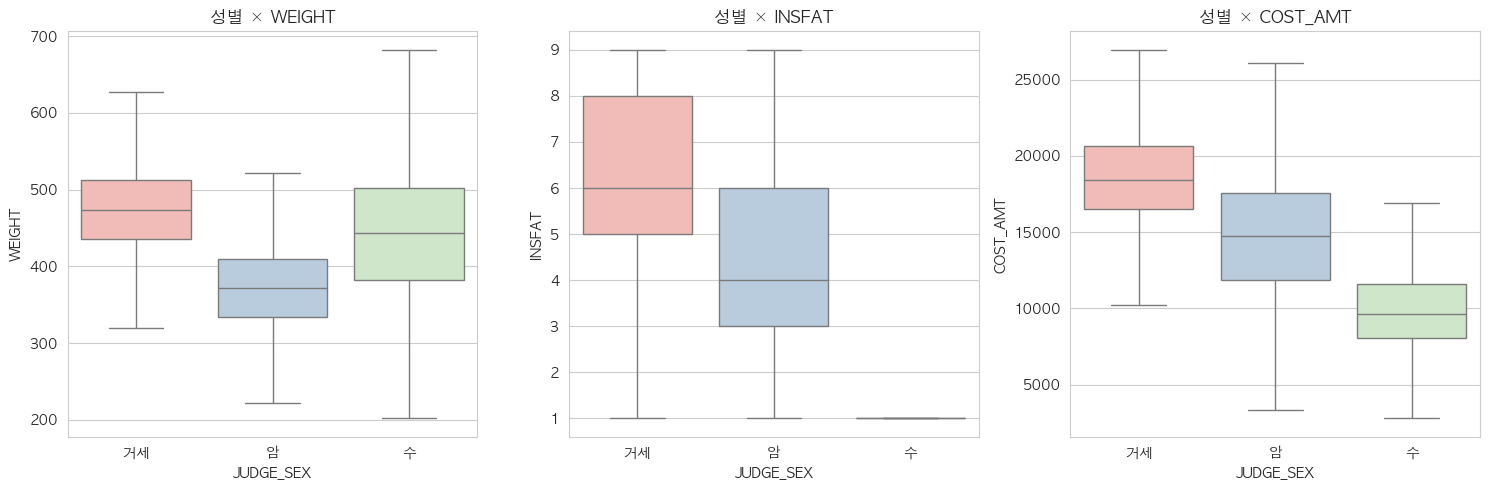

In [9]:
plot_vars = [v for v in ["WEIGHT","INSFAT",target] if v in df.columns]
fig, axes = plt.subplots(1, len(plot_vars), figsize=(5*len(plot_vars), 5))
for ax, var in zip(axes, plot_vars):
    sns.boxplot(data=df, x="JUDGE_SEX", y=var, order=["거세","암","수"],
                hue="JUDGE_SEX", hue_order=["거세","암","수"],
                palette="Pastel1", legend=False, ax=ax, showfliers=False)
    ax.set_title(f"성별 × {var}")
plt.tight_layout()
plt.savefig("../../figures/14_box_sex.png", dpi=100, bbox_inches="tight")
plt.show()

## 8. 통계 검정 — 차이가 진짜인가 (전부 Kruskal-Wallis)

In [10]:
# 성별 (3그룹)
sexes = ["거세","암","수"]
groups_w = [df[df["JUDGE_SEX"]==s]["WEIGHT"].dropna() for s in sexes]
groups_w = [g for g in groups_w if len(g) > 0]
print("=== 성별 × 도체중 ===")
for s, g in zip(sexes, groups_w):
    print(f"  {s}: 중앙값={g.median():.1f}, N={len(g):,}")
h, p = kruskal(*groups_w)
print(f"Kruskal-Wallis: H={h:.1f}, p={p:.4g}")
print(f"  → {'성별 간 차이 유의' if p < 0.05 else '유의하지 않음'}")

=== 성별 × 도체중 ===
  거세: 중앙값=473.0, N=1,222,465
  암: 중앙값=372.0, N=1,174,414
  수: 중앙값=443.0, N=11,820


Kruskal-Wallis: H=1088062.9, p=0
  → 성별 간 차이 유의


In [11]:
# 계절 (4그룹)
seasons = ["봄","여름","가을","겨울"]
groups_c = [df[df["abatt_season"]==s][target].dropna() for s in seasons]
h, p = kruskal(*groups_c)
print(f"계절 × 가격 Kruskal-Wallis: H={h:.1f}, p={p:.4g}")

계절 × 가격 Kruskal-Wallis: H=80818.7, p=0


In [12]:
# 등급 (16그룹) — 도축 전 변수가 등급과 관련 있는가
groups_g = [df[df["LAST_GRADE"]==g]["WEIGHT"].dropna() for g in grade_order]
groups_g = [g for g in groups_g if len(g) > 0]
h, p = kruskal(*groups_g)
print(f"등급 × 도체중 Kruskal-Wallis: H={h:.1f}, p={p:.4g}")
print("  → 유의하면 WEIGHT가 등급 예측에 유용 (도축 전에도 아는 값)")

등급 × 도체중 Kruskal-Wallis: H=697821.7, p=0
  → 유의하면 WEIGHT가 등급 예측에 유용 (도축 전에도 아는 값)


## 9. 저장

In [13]:
df.to_csv("../../data/processed/3_eda/step8_scatter.csv",
          index=False, encoding="utf-8-sig")
print(f"저장 완료: step8_scatter.csv {df.shape}")

저장 완료: step8_scatter.csv (2408699, 46)
